<a href="https://colab.research.google.com/github/contactdilarayilmaz/asteroid-classification/blob/main/Colab%20Notebooks/05_feature_engineering_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NASA Asteroid Sınıflandırma Projesi
## Notebook 05 — Feature Engineering & Kapsamlı Model Karşılaştırması

**Bu notebook'ta yapacaklarımız:**

1. Notebook 02'den kaydedilen ham (unscaled) veriyi yükle
2. SHAP bulgularına dayalı fiziksel anlamlı yeni özellikler türet:
   - `est_diameter_km` — Mutlak parlaklıktan (H) albedo varsayımıyla çap tahmini
   - `velocity_x_distance` — Hız-mesafe etkileşim terimi
   - `size_velocity_ratio` — Boyut/hız oranı (küçük + hızlı = daha tehlikeli)
   - `log_miss_distance` — Çarpık dağılımı düzeltmek için logaritmik dönüşüm
   - `log_relative_velocity` — Çarpık dağılımı düzeltmek için logaritmik dönüşüm
   - `magnitude_squared` — Parlaklığın doğrusal olmayan etkisi (H²)
3. FE sonrası veriyi yeniden ölçekle (StandardScaler) ve modelleri eğit
4. Random Forest (FE) ve XGBoost (FE) performansını ham özellik setleriyle karşılaştır
5. Tüm notebookların (02 + 05) sonuçlarını `fe_metrics.json`'a kaydet
6. Radar chart ile tüm modellerin çok-metrikli karşılaştırmasını görselleştir
7. F1 skoruna göre genel şampiyon modeli belirle

> ⚠️ **Kritik Hatırlatma:** Sınıf dengesizliği %9.7 PHA. Accuracy'ye değil, **Recall** ve **F1-Score** (minority class) metriklerine odaklanılmalı! Hedef: Recall (PHA) ≥ 0.85, F1 (PHA) ≥ 0.80

> **Feature Engineering Hipotezi:** SHAP analizi `est_diameter_min`'in `absolute_magnitude`'dan türetilebileceğini gösterdi. Bu notebook doğrudan fizik formülüyle çap hesaplayarak bağımsız bir özellik seti oluşturmayı deniyor.

> Not: Bu notebook Google Colab'da çalıştırılmak üzere hazırlanmıştır.

⚠️ Öncesinde **Notebook 02**'nin çalıştırılmış olması gerekir (`baseline_metrics.json` Drive'da mevcut olmalı).

---
*Önceki adım:* `04_neural_network_challenge.ipynb`

In [1]:
!pip install torch torchvision imbalanced-learn shap xgboost -q
print('✅ Kütüphaneler hazır!')

✅ Kütüphaneler hazır!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — Modeller
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Scikit-learn — Değerlendirme
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# SHAP
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Görsel stil ayarları
plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)

print('✅ Import işlemi tamamlandı!')

✅ Import işlemi tamamlandı!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/nasa_asteroid/'

X_train_raw = pd.read_csv(DRIVE_PATH + 'X_train_raw.csv')
y_train     = pd.read_csv(DRIVE_PATH + 'y_train.csv').squeeze()
y_test      = pd.read_csv(DRIVE_PATH + 'y_test.csv').squeeze()
# Test için ham (unscaled) veriyi oluştur — FE sonrası yeniden scale edeceğiz
X_test_raw  = pd.read_csv(DRIVE_PATH + 'X_test.csv')
print('✅ Drive\'dan yüklendi')

print(f'\nTrain: {X_train_raw.shape[0]:,} × {X_train_raw.shape[1]} | '
      f'Test: {X_test_raw.shape[0]:,} × {X_test_raw.shape[1]}')
print(f'PHA oranı — Train: %{y_train.mean()*100:.1f} | Test: %{y_test.mean()*100:.1f}')
print(f'Özellikler: {list(X_train_raw.columns)}')

Mounted at /content/drive
✅ Drive'dan yüklendi

Train: 72,668 × 4 | Test: 18,168 × 4
PHA oranı — Train: %9.7 | Test: %9.7
Özellikler: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']


## Feature Engineering — Fiziksel Anlamlı Yeni Özellikler

Notebook 02'deki SHAP analizi hangi özelliklerin belirleyici olduğunu gösterdi.
Bu bilgiyi kullanarak fiziksel açıdan anlamlı yeni değişkenler türetiyoruz.

| Yeni Özellik | Formül / Mantık | Fiziksel Yorum |
|---|---|---|
| `est_diameter_km` | `(1329/√0.15) × 10^(-H/5)` | H'den çap tahmini (albedo p=0.15) |
| `velocity_x_distance` | `v × d / 1e9` | Hız-mesafe etkileşimi |
| `size_velocity_ratio` | `diameter / velocity` | Küçük+hızlı = daha tehlikeli |
| `log_miss_distance` | `log(1 + miss_dist)` | Çarpık dağılımı düzelt |
| `log_relative_velocity` | `log(1 + velocity)` | Çarpık dağılımı düzelt |
| `magnitude_squared` | `H²` | Non-lineer parlaklık etkisi |

In [4]:
def add_features(X, verbose=True):
    Xf = X.copy()

    if 'absolute_magnitude' in Xf.columns:
        Xf['est_diameter_km'] = (1329 / np.sqrt(0.15)) * 10**(-Xf['absolute_magnitude'] / 5)
        Xf['magnitude_squared'] = Xf['absolute_magnitude'] ** 2

    if 'relative_velocity' in Xf.columns and 'miss_distance' in Xf.columns:
        Xf['velocity_x_distance'] = (Xf['relative_velocity'] * Xf['miss_distance']) / 1e9

    if 'est_diameter_min' in Xf.columns and 'relative_velocity' in Xf.columns:
        Xf['size_velocity_ratio'] = Xf['est_diameter_min'] / (Xf['relative_velocity'] + 1e-9)

    for col in ['miss_distance', 'relative_velocity', 'est_diameter_min']:
        if col in Xf.columns:
            Xf[f'log_{col}'] = np.log1p(np.abs(Xf[col]))

    if verbose:
        new = [c for c in Xf.columns if c not in X.columns]
        print(f'✅ Feature Engineering: {X.shape[1]} → {Xf.shape[1]} özellik')
        print(f'   Yeni özellikler: {new}')
    return Xf

X_train_fe = add_features(X_train_raw, verbose=True)
X_test_fe  = add_features(X_test_raw,  verbose=False)

✅ Feature Engineering: 4 → 11 özellik
   Yeni özellikler: ['est_diameter_km', 'magnitude_squared', 'velocity_x_distance', 'size_velocity_ratio', 'log_miss_distance', 'log_relative_velocity', 'log_est_diameter_min']


In [5]:
from sklearn.preprocessing import StandardScaler

print('⏳ Ölçeklendirme (Scaling) yapılıyor...')

# Yeni bir scaler objesi oluştur
scaler_fe = StandardScaler()

# Scaler'ı SADECE X_train_fe ile eğit (fit) ve dönüştür (transform)
X_train_fe_scaled = pd.DataFrame(scaler_fe.fit_transform(X_train_fe), columns=X_train_fe.columns)

# Aynı scaler kurallarını X_test_fe'ye sadece uygula (transform)
X_test_fe_scaled = pd.DataFrame(scaler_fe.transform(X_test_fe), columns=X_test_fe.columns)

print(f'✅ Ölçeklendirme tamamlandı!')
display(X_train_fe_scaled.head(5)) # Verinin nasıl değiştiğine bir göz at

⏳ Ölçeklendirme (Scaling) yapılıyor...
✅ Ölçeklendirme tamamlandı!


,est_diameter_min,relative_velocity,miss_distance,absolute_magnitude,est_diameter_km,magnitude_squared,velocity_x_distance,size_velocity_ratio,log_miss_distance,log_relative_velocity,log_est_diameter_min
0,-0.3316,-0.1882,0.4943,0.5778,-0.3316,0.5399,0.0638,-0.1981,0.5571,0.0788,-0.5395
1,-0.3125,-1.0407,0.8667,0.4122,-0.3125,0.3631,-0.4045,-0.1321,0.6973,-1.1055,-0.5010
2,0.2342,2.4271,1.2194,-1.0094,0.2342,-1.0141,2.7751,-0.0958,0.8121,1.6743,0.5131
3,0.1020,1.2051,0.8440,-0.8368,0.1020,-0.8603,1.3272,-0.0802,0.6893,1.1032,0.2816
4,-0.3866,-1.1474,0.0561,1.5094,-0.3866,1.5973,-0.6769,-0.2135,0.3571,-1.3329,-0.6514


In [6]:
import pickle
import os

print("⏳ Veriler Google Drive'a kaydediliyor...")

# Zenginleştirilmiş verileri CSV olarak kaydet
X_train_fe_scaled.to_csv(DRIVE_PATH + 'X_train_fe_scaled.csv', index=False)
X_test_fe_scaled.to_csv(DRIVE_PATH + 'X_test_fe_scaled.csv', index=False)

# Daha sonra canlı veri gelirse aynı ölçeklendirmeyi yapabilmek için scaler'ı da kaydet
with open(DRIVE_PATH + 'scaler_fe.pkl', 'wb') as f:
    pickle.dump(scaler_fe, f)

print('💾 Başarılı! Aşağıdaki dosyalar oluşturuldu:')
print('  ✅ X_train_fe_scaled.csv')
print('  ✅ X_test_fe_scaled.csv')
print('  ✅ scaler_fe.pkl')
print('\n🚀 Artık Baseline (02) ve Neural Network (04) scriptlerinde bu yeni CSV dosyalarını okuyarak eğitim yapabilirsin.')

⏳ Veriler Google Drive'a kaydediliyor...
💾 Başarılı! Aşağıdaki dosyalar oluşturuldu:
  ✅ X_train_fe_scaled.csv
  ✅ X_test_fe_scaled.csv
  ✅ scaler_fe.pkl

🚀 Artık Baseline (02) ve Neural Network (04) scriptlerinde bu yeni CSV dosyalarını okuyarak eğitim yapabilirsin.


⚠️ Not: 6. cell sonrasında  **Notebook 02** ve **Notebook 04**'ün çalıştırılmış olması gerekir (`random_forest.pkl`, `xgboost.pkl`,`random_forest_fe.pkl` , `xgboost_fe.pkl`  Drive'da mevcut olmalı).


In [7]:
import pickle

# Base Modelleri yükle
with open(DRIVE_PATH + 'random_forest.pkl', 'rb') as f:
    rf_base_loaded = pickle.load(f)

with open(DRIVE_PATH + 'xgboost.pkl', 'rb') as f:
    xgb_base_loaded = pickle.load(f)

print('\n✅ Modeller yüklendi')
print(f'   RF özellikleri: {rf_base_loaded.n_features_in_}')
print(f'   XGB özellikleri: {xgb_base_loaded.n_features_in_}')


✅ Modeller yüklendi
   RF özellikleri: 4
   XGB özellikleri: 4


In [8]:
# FE Eklenmiş Modelleri yükle

with open(DRIVE_PATH + 'random_forest_fe.pkl', 'rb') as f:
    rf_fe_loaded = pickle.load(f)

with open(DRIVE_PATH + 'xgboost_fe.pkl',       'rb') as f:
    xgb_fe_loaded = pickle.load(f)

print('\n✅ Modeller yüklendi')
print(f'   RF özellikleri (FE): {rf_fe_loaded.n_features_in_}')
print(f'   XGB özellikleri (FE): {xgb_fe_loaded.n_features_in_}')


✅ Modeller yüklendi
   RF özellikleri (FE): 11
   XGB özellikleri (FE): 11


## 5. Tum Modellerin Karsilastirmasi (Drive'dan JSON Yukle)

`baseline_metrics.json` (02 notebook'tan) ve `fe_metrics.json` (04 notebook'tan)
dosyalari Drive'dan okunarak tek bir karsilastirma tablosu ve radar chart olusturulur.

  baseline_metrics.json yuklendi (5 kayit)
  fe_metrics.json yuklendi (2 kayit)

Tum Modeller Karsilastirma Tablosu:


,model_name,notebook,feature_set,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,02_baseline,raw,0.8754,0.4220,0.7585,0.5423,0.9327,0.5836
1,XGBoost,02_baseline,raw,0.8115,0.3353,0.9536,0.4962,0.9242,0.5530
2,Logistic Regression,02_baseline,raw,0.7859,0.3042,0.9321,0.4587,0.8794,0.3262
3,SVM (RBF),02_baseline,raw,0.7687,0.2955,0.9943,0.4556,0.8973,0.4177
4,KNN (k=11),02_baseline,raw,0.9079,0.5506,0.2890,0.3791,0.9024,0.5129
5,XGBoost (FE),04_neural_network,fe,0.8443,0.3083,0.4825,0.3762,0.6720,0.2369
6,Random Forest (FE),04_neural_network,fe,0.5779,0.1426,0.6657,0.2349,0.6529,0.1798


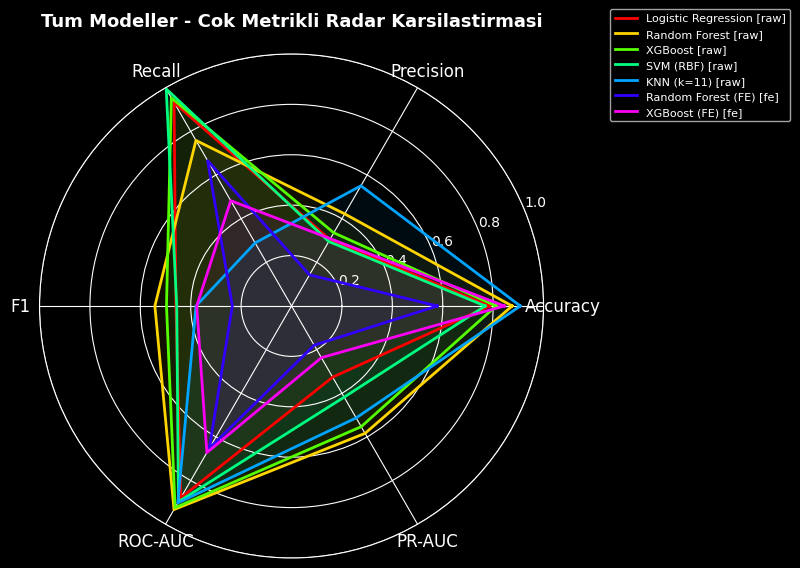

all_models_radar.png kaydedildi


In [9]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

# ─── evaluate_trained_model — Evrensel degerlendirme fonksiyonu ───────────────
def evaluate_trained_model(model, X_test, y_test,
                            model_name='Model',
                            notebook='unknown',
                            feature_set='raw',
                            threshold=0.5):
    """
    Egitilmis bir modeli degerlendirir ve standart metrik sozlugu dondurur.
    Sklearn (predict_proba / decision_function) ve PyTorch nn.Module destekler.
    """
    y_true = np.array(y_test).ravel()

    try:
        import torch, torch.nn as nn
        is_torch = isinstance(model, nn.Module)
    except ImportError:
        is_torch = False

    if is_torch:
        model.eval()
        X_arr = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
        with torch.no_grad():
            logits = model(torch.FloatTensor(X_arr))
            y_proba = torch.sigmoid(logits).cpu().numpy().ravel()
    elif hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        raise ValueError(f'Model turu desteklenmiyor: {type(model)}')

    y_pred = (y_proba >= threshold).astype(int)

    return {
        'model_name'  : model_name,
        'notebook'    : notebook,
        'feature_set' : feature_set,
        'Accuracy'    : round(float(accuracy_score(y_true, y_pred)), 6),
        'Precision'   : round(float(precision_score(y_true, y_pred, zero_division=0)), 6),
        'Recall'      : round(float(recall_score(y_true, y_pred, zero_division=0)), 6),
        'F1'          : round(float(f1_score(y_true, y_pred, zero_division=0)), 6),
        'ROC-AUC'     : round(float(roc_auc_score(y_true, y_proba)), 6),
        'PR-AUC'      : round(float(average_precision_score(y_true, y_proba)), 6),
    }


# ─── Drive'dan JSON dosyalarini yukle ─────────────────────────────────────────
all_metrics_combined = []
for json_file in ['baseline_metrics.json', 'fe_metrics.json']:
    fpath = DRIVE_PATH + json_file
    if os.path.exists(fpath):
        with open(fpath, 'r') as f:
            data = json.load(f)
        all_metrics_combined.extend(data)
        print(f'  {json_file} yuklendi ({len(data)} kayit)')
    else:
        print(f'  UYARI: {json_file} bulunamadi')

if not all_metrics_combined:
    print('Hicbir JSON bulunamadi. Once 02 ve 04 notebook larini calistir.')
else:
    METRIC_KEYS = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
    comparison_df = pd.DataFrame(all_metrics_combined)
    display_cols  = ['model_name', 'notebook', 'feature_set'] + METRIC_KEYS
    display_cols  = [c for c in display_cols if c in comparison_df.columns]

    print('\nTum Modeller Karsilastirma Tablosu:')
    pd.set_option('display.float_format', '{:.4f}'.format)
    display(comparison_df[display_cols].sort_values('F1', ascending=False).reset_index(drop=True))

    # ─── Radar Chart ──────────────────────────────────────────────────────────
    radar_metrics = METRIC_KEYS
    N      = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    colors  = plt.cm.hsv(np.linspace(0, 0.85, len(comparison_df)))

    for idx, row in comparison_df.iterrows():
        values = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
        label  = f"{row.get('model_name','?')} [{row.get('feature_set','?')}]"
        ax.plot(angles, values, linewidth=2, label=label, color=colors[idx])
        ax.fill(angles, values, alpha=0.07, color=colors[idx])

    ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Tum Modeller - Cok Metrikli Radar Karsilastirmasi',
                 fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), fontsize=8)
    plt.tight_layout()
    plt.savefig(DRIVE_PATH + 'all_models_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('all_models_radar.png kaydedildi')


In [10]:
METRIC_KEYS = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

# F1'e göre en iyi modeli bul
best_row = comparison_df.loc[comparison_df['F1'].idxmax()]

print('=' * 65)
print('🏆  EN İYİ MODEL (F1 Skoruna Göre)')
print('=' * 65)
print(f"  Model        : {best_row.get('model_name', '?')}")
print(f"  Notebook     : {best_row.get('notebook', '?')}")
print(f"  Feature Set  : {best_row.get('feature_set', '?')}")
print()
for k in METRIC_KEYS:
    bar_len = int(best_row[k] * 30)
    bar     = '█' * bar_len + '░' * (30 - bar_len)
    print(f"  {k:<12}: {best_row[k]:.4f}  [{bar}]")

print()
print('─' * 65)
print('📊  METRİK BAZINDA KAZANANLAR:')
print('─' * 65)
for k in METRIC_KEYS:
    winner = comparison_df.loc[comparison_df[k].idxmax()]
    name   = winner.get('model_name', '?')
    fs     = winner.get('feature_set', '?')
    print(f"  {k:<12}: {name} [{fs}]  →  {winner[k]:.4f}")

print()
print('─' * 65)
print('📋  TAM SIRALAMA (F1 ↓):')
print('─' * 65)
rank_df = comparison_df[['model_name', 'feature_set'] + METRIC_KEYS].sort_values('F1', ascending=False).reset_index(drop=True)
rank_df.index += 1
print(rank_df.to_string())


🏆  EN İYİ MODEL (F1 Skoruna Göre)
  Model        : Random Forest
  Notebook     : 02_baseline
  Feature Set  : raw

  Accuracy    : 0.8754  [██████████████████████████░░░░]
  Precision   : 0.4220  [████████████░░░░░░░░░░░░░░░░░░]
  Recall      : 0.7585  [██████████████████████░░░░░░░░]
  F1          : 0.5423  [████████████████░░░░░░░░░░░░░░]
  ROC-AUC     : 0.9327  [███████████████████████████░░░]
  PR-AUC      : 0.5836  [█████████████████░░░░░░░░░░░░░]

─────────────────────────────────────────────────────────────────
📊  METRİK BAZINDA KAZANANLAR:
─────────────────────────────────────────────────────────────────
  Accuracy    : KNN (k=11) [raw]  →  0.9079
  Precision   : KNN (k=11) [raw]  →  0.5506
  Recall      : SVM (RBF) [raw]  →  0.9943
  F1          : Random Forest [raw]  →  0.5423
  ROC-AUC     : Random Forest [raw]  →  0.9327
  PR-AUC      : Random Forest [raw]  →  0.5836

─────────────────────────────────────────────────────────────────
📋  TAM SIRALAMA (F1 ↓):
────────────────

 ⏭️ Notebook'lar tamamlandı simülatöre geçebilirsiniz.


Web simülatör uygulamasını açabilmeniz için terminale sırasıyla şu komutları girmeniz gereklidir:

> pip install -r requirements.txt
>
> cd "C:\Users\...\asteroid-classification\simulator"
>
> python app.py

> Anaconda kullanıyorsanız:
>
> C:\Users\...\anaconda3\python.exe app.py

Sonrasında tarayıcıda http://127.0.0.1:5000 adresini açmak yeterlidir.